<a href="https://colab.research.google.com/github/c-marq/AI-Thinking-CAI1001C/blob/main/06-Intro-to-ML/Guided-Project/LiveDemo_Predicting_Restaurant_Revenue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🍽️ Live Demo: Predicting Restaurant Revenue

**CAI1001C: AI Thinking | Miami Dade College**
**Weeks 5 & 6 — Data Visualization + Introduction to Machine Learning**

---

### What We're Building Today

We have data from **60 Miami restaurants**. Each restaurant has information like seating capacity, average meal price, Yelp rating, and years in business.

**Our goal:** Can a computer learn from this data to **predict monthly revenue** for a new restaurant?

This is **machine learning** — and you're about to see it happen live.

---

**The ML Workflow (from today's slides):**
1. ✅ Load and explore the data
2. ✅ Visualize it (Ch 5 callback!)
3. ✅ Pick features and label
4. ✅ Split into training and test sets
5. ✅ Train the model
6. ✅ Evaluate how well it learned
7. ✅ Make a prediction


In [1]:
# ============================================
# SETUP — Run this cell first
# Installs and imports everything we need
# ============================================

# Data tools (you already know these from Ch 3-4)
import pandas as pd
import numpy as np

# Visualization tools (Ch 5)
import matplotlib.pyplot as plt

# Machine learning tools (Ch 6 — NEW!)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

print("✅ All libraries loaded. Let's go!")


✅ All libraries loaded. Let's go!


---

## Step 1: Load and Explore the Data

First, let's load our Miami restaurant dataset and see what we're working with. This is the same pandas work you've been doing since Chapter 3 — nothing new here.


In [2]:
# ============================================
# Step 1: Load the Miami restaurant dataset
# ============================================

# Load the CSV file into a DataFrame
df = pd.read_csv("miami_restaurants.csv")

# How big is our dataset?
print(f"Our dataset has {df.shape[0]} restaurants and {df.shape[1]} columns")
print()

# Let's see the first 5 rows
df.head()


Our dataset has 60 restaurants and 7 columns



,restaurant_name,seating_capacity,avg_meal_price,yelp_rating,num_employees,years_open,monthly_revenue
0,Sabor de Casa,71,16.92,3.0,20,22,37533
1,Café Cubano Express,112,33.28,3.6,30,11,47630
2,La Ventanita,34,30.57,3.8,8,16,40111
3,El Rincón de Abuela,91,38.83,4.4,31,16,58824
4,Biscayne Bites,80,14.41,4.9,28,1,40901


In [3]:
# ============================================
# Quick data exploration — what are we working with?
# ============================================

# Summary statistics for the numeric columns
df.describe().round(2)


,seating_capacity,avg_meal_price,yelp_rating,num_employees,years_open,monthly_revenue
count,60.00,60.00,60.00,60.00,60.00,60.00
mean,69.25,26.87,3.76,17.62,12.08,42569.27
std,29.62,10.28,0.59,8.24,7.40,7407.42
min,21.00,8.52,2.30,4.00,1.00,24841.00
25%,40.75,18.20,3.30,11.00,5.75,36461.75
50%,73.00,28.37,3.80,18.00,11.00,42940.50
75%,94.00,34.75,4.12,23.25,19.00,47676.00
max,119.00,43.95,5.00,36.00,24.00,58824.00


---

## Step 2: Visualize the Data (Chapter 5 Callback!)

Before we build any model, let's **look** at the data. Remember from the slides: a good chart can show you patterns in seconds.

**Question:** Is there a relationship between Yelp rating and monthly revenue?


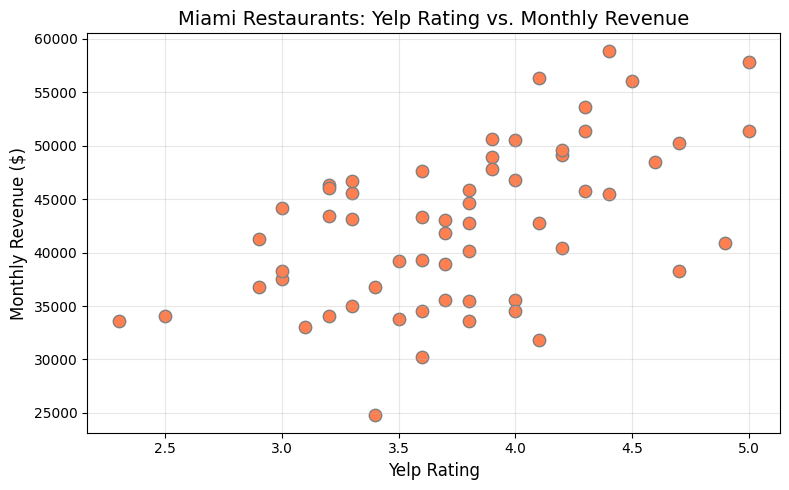

👆 Can you see a pattern? Higher ratings tend to mean higher revenue.
   But it's not perfect — there's scatter. That's real data for you.


In [4]:
# ============================================
# Step 2: Scatter plot — Yelp Rating vs. Revenue
# Question: Do higher-rated restaurants make more money?
# ============================================

plt.figure(figsize=(8, 5))
plt.scatter(df["yelp_rating"], df["monthly_revenue"], color="coral", edgecolors="gray", s=80)
plt.xlabel("Yelp Rating", fontsize=12)
plt.ylabel("Monthly Revenue ($)", fontsize=12)
plt.title("Miami Restaurants: Yelp Rating vs. Monthly Revenue", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("👆 Can you see a pattern? Higher ratings tend to mean higher revenue.")
print("   But it's not perfect — there's scatter. That's real data for you.")


---

## Step 3: Pick Features and Label

This is the KEY decision in machine learning.

- **Features (X)** = the inputs the model uses to make predictions
- **Label (y)** = the output we're trying to predict

**Our features:** seating_capacity, avg_meal_price, yelp_rating, years_open

**Our label:** monthly_revenue

> 🤔 **Why not include `restaurant_name`?** Names are just text labels — they don't help predict revenue. The model needs numbers with patterns.
>
> 🤔 **Why not include `num_employees`?** Think about it — employee count is closely tied to seating capacity. Including both can confuse the model. We keep it simple.


In [5]:
# ============================================
# Step 3: Define our features (X) and label (y)
# ============================================

# Features — the information the model gets to look at
X = df[["seating_capacity", "avg_meal_price", "yelp_rating", "years_open"]]

# Label — what we want the model to predict
y = df["monthly_revenue"]

print("Features (X):")
print(X.head())
print()
print("Label (y) — first 5 values:")
print(y.head())
print()
print(f"We have {X.shape[0]} restaurants and {X.shape[1]} features.")


Features (X):
   seating_capacity  avg_meal_price  yelp_rating  years_open
0                71           16.92          3.0          22
1               112           33.28          3.6          11
2                34           30.57          3.8          16
3                91           38.83          4.4          16
4                80           14.41          4.9           1

Label (y) — first 5 values:
0    37533
1    47630
2    40111
3    58824
4    40901
Name: monthly_revenue, dtype: int64

We have 60 restaurants and 4 features.


---

## Step 4: Split into Training and Test Sets

Remember from the slides: **you can't test a student with the same exam they studied from.**

- **Training set (80%)** — the model learns patterns from this data
- **Test set (20%)** — we check if the model actually learned, or just memorized

This is how we keep the model honest.


In [6]:
# ============================================
# Step 4: Split into training (80%) and test (20%) sets
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% for testing
    random_state=42      # Makes the split reproducible
)

print(f"Training set: {X_train.shape[0]} restaurants (the model learns from these)")
print(f"Test set:     {X_test.shape[0]} restaurants (we test the model on these)")
print()
print("The model will NEVER see the test set during training.")
print("This is how we know if it truly learned the patterns.")


Training set: 48 restaurants (the model learns from these)
Test set:     12 restaurants (we test the model on these)

The model will NEVER see the test set during training.
This is how we know if it truly learned the patterns.


---

## Step 5: Train the Model

Here it is — the moment machine learning happens.

We're using **Linear Regression** — it finds the best-fit line through the data. Think of it as drawing a trend line, but mathematically optimized across all 4 features at once.

**This takes 2 lines of code.** Seriously.


In [7]:
# ============================================
# Step 5: Train the model — this is where ML happens!
# ============================================

# Create the model
model = LinearRegression()

# Train it on our training data
model.fit(X_train, y_train)

print("✅ Model trained!")
print()
print("That's it. Two lines of code.")
print("The model just analyzed 48 restaurants and found the patterns.")


✅ Model trained!

That's it. Two lines of code.
The model just analyzed 48 restaurants and found the patterns.


---

## Step 6: How Well Did It Learn?

Two things to check:

1. **Coefficients** — How much does each feature influence the prediction?
2. **R² Score** — Overall, how well does the model explain the data? (0 = terrible, 1 = perfect)


In [8]:
# ============================================
# Step 6a: Look at the coefficients
# What did the model learn about each feature?
# ============================================

print("What the model learned about each feature:")
print("=" * 50)

for feature, coef in zip(X.columns, model.coef_):
    direction = "⬆️ increases" if coef > 0 else "⬇️ decreases"
    print(f"  {feature:20s} → ${coef:,.0f} per unit ({direction} revenue)")

print()
print("Translation:")
print("  • Each additional SEAT adds ~$182 to monthly revenue")
print("  • Each $1 increase in meal price adds ~$260 to monthly revenue")
print("  • Each Yelp STAR adds ~$4,150 to monthly revenue  ← BIGGEST impact!")
print("  • Each YEAR in business adds ~$324 to monthly revenue")


What the model learned about each feature:
  seating_capacity     → $182 per unit (⬆️ increases revenue)
  avg_meal_price       → $260 per unit (⬆️ increases revenue)
  yelp_rating          → $4,150 per unit (⬆️ increases revenue)
  years_open           → $324 per unit (⬆️ increases revenue)

Translation:
  • Each additional SEAT adds ~$182 to monthly revenue
  • Each $1 increase in meal price adds ~$260 to monthly revenue
  • Each Yelp STAR adds ~$4,150 to monthly revenue  ← BIGGEST impact!
  • Each YEAR in business adds ~$324 to monthly revenue


In [9]:
# ============================================
# Step 6b: R² Score — how well does the model fit?
# ============================================

# Score on TRAINING data (what it learned from)
train_score = model.score(X_train, y_train)

# Score on TEST data (what it's never seen before)
test_score = model.score(X_test, y_test)

print(f"R² on training data: {train_score:.2f}")
print(f"R² on test data:     {test_score:.2f}")
print()

if test_score > 0.7:
    print("🎉 Not bad! The model explains about {:.0f}% of the variation in revenue.".format(test_score * 100))
    print("   That means it's capturing real patterns — not just guessing.")
else:
    print("🤔 The model captured some patterns but there's room for improvement.")

print()
print("Note: The scores are similar — that means the model isn't overfitting.")
print("(Remember: overfitting = memorizing the exam instead of learning the material)")


R² on training data: 0.86
R² on test data:     0.77

🎉 Not bad! The model explains about 77% of the variation in revenue.
   That means it's capturing real patterns — not just guessing.

Note: The scores are similar — that means the model isn't overfitting.
(Remember: overfitting = memorizing the exam instead of learning the material)


---

## Step 7: Make a Prediction! 🔮

Now the fun part. Let's say **Sofia** — from our textbook — is planning to open a new restaurant in Hialeah.

Here's what she's planning:
- **50 seats**
- **Average meal price: $18**
- **Current Yelp rating: 4.3** (from her food truck reviews)
- **Years in business: 3** (she's been running the food truck)

**Can our model predict her monthly revenue?**


In [10]:
# ============================================
# Step 7: Predict revenue for Sofia's new restaurant
# ============================================

# Sofia's restaurant details
sofia_restaurant = pd.DataFrame({
    "seating_capacity": [50],
    "avg_meal_price": [18.00],
    "yelp_rating": [4.3],
    "years_open": [3]
})

# Make the prediction
predicted_revenue = model.predict(sofia_restaurant)[0]

print("🍽️  Sofia's Restaurant Plan")
print("=" * 40)
print(f"  Seats:           50")
print(f"  Avg meal price:  $18.00")
print(f"  Yelp rating:     4.3 ⭐")
print(f"  Years open:      3")
print()
print(f"  💰 Predicted monthly revenue: ${predicted_revenue:,.0f}")
print()
print("Is this a guarantee? NO.")
print("It's the model's best estimate based on patterns from 48 other restaurants.")
print("Real revenue depends on location, marketing, competition, and a hundred other things.")
print("But it's a data-informed starting point — way better than guessing.")


🍽️  Sofia's Restaurant Plan
  Seats:           50
  Avg meal price:  $18.00
  Yelp rating:     4.3 ⭐
  Years open:      3

  💰 Predicted monthly revenue: $36,220

Is this a guarantee? NO.
It's the model's best estimate based on patterns from 48 other restaurants.
Real revenue depends on location, marketing, competition, and a hundred other things.
But it's a data-informed starting point — way better than guessing.


---

## What Just Happened?

You just watched a machine **learn from data** and **make a prediction** — in under 20 lines of code.

| Step | What We Did | Slide Reference |
|------|------------|-----------------|
| 1 | Loaded and explored data | Ch 3-4 skills |
| 2 | Visualized with a scatter plot | Ch 5 — Data Viz |
| 3 | Picked features (X) and label (y) | Slide 15 |
| 4 | Split into train/test sets | Slide 16 |
| 5 | Trained a Linear Regression model | Slide 17 |
| 6 | Read coefficients and R² score | Slide 18 |
| 7 | Predicted revenue for a new restaurant | The payoff! |

**Key takeaway:** The Yelp rating had the biggest impact on revenue ($4,150 per star). If Sofia wants to maximize revenue, maintaining her rating matters more than adding seats.

---

### 🤔 Think About It

- What if the training data only had high-end restaurants? Would the model work for Sofia's casual spot?
- What if most restaurants in the data were in Brickell? Would it predict well for Hialeah?
- **Whose data trains the model matters.** Remember that for your Friday assignment.

---

*Next up: Group lab activity!*
